# Random Walk Simulation
A random walk is a process in which a particle can take a step in a random direction of fixed length (in this case), $a$. We can see that intuitively the average *vector* displacement of the particle is 0. However, the average distance from the origin is in fact not constant.

### To improve
- To better utilise all of the data gathered, create a new function that also returns the average distance squared at each step, and then generate trajectories. This means that we can utilise each trajectory for every single data point. However, this does mean that the data might be a bit more noisy, since the power of this simulation is in the randomness...

## Load libraries

In [36]:
# Handling large arrays
import numpy as np

# Plotting / graphics
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# Set figure resolution
plt.rcParams['figure.dpi'] = 200

## Default parameters of the simulation

In [37]:
# Size of the steps
step_size = 10

# Number of steps to take in a walk
length = 10000

# Number of walks to generate
iterations = 1000

## Generate a random walk

In [38]:
def randomWalkGenerator(length=length, step_size=step_size):

    # Start at the origin
    path = np.array([[0, 0]])

    for _ in range(length):
        
        # Create a random vector, could also be done using angles
        next_step_raw = np.random.random(2) * 2 - 1

        # Normalise the step
        next_step = step_size * next_step_raw / np.linalg.norm(next_step_raw)

        # Add new position to path
        path = np.append(path, [path[-1] + next_step], axis=0)

    # Return the walk
    return path

## Graphics - plotting the path

In [39]:
# Returns the lines that need to be drawn
def lineGenerator(path, length):
    colors = np.array([])
    lines = np.array([[path[0], path[1]]])
    for i in range(1, length):
        lines = np.append(lines, [[path[i], path[i + 1]]], axis=0)
        colors = np.append(colors, "black")
    return lines, colors

# Plots the entire path
def plot_path(path, lines, colors):
    max_points = path.max(axis=0)
    min_points = path.min(axis=0)

    lc = LineCollection(lines, colors=colors, linewidths=1)
    fig, ax = plt.subplots()
    ax.set_xlim(min_points[0] - 5, max_points[0] + 5)
    ax.set_ylim(min_points[1] - 5, max_points[1] + 5)
    ax.set_aspect("equal")
    ax.add_collection(lc)
    ax.plot(path[-1][0], path[-1][1], "ro")
    ax.plot(0, 0, "bo")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Randomly Generated Walk")
    plt.show()

## Generate final displacements

In [40]:
def generateDisplacements(iterations=iterations, length=length, step_size=step_size):

    # Create array of final vector displacments
    vector_displacements = np.array([])

    # Loop over iterations
    for i in range(iterations):

        # Generate a walk
        path = randomWalkGenerator(length)

        # Determine final displacement
        vector_disp = path[-1]

        # Append to arrow
        vector_displacements = np.append(vector_displacements, [vector_disp])

    # Reshape and return
    return vector_displacements.reshape([iterations, 2])

## Determine average vector displacment

In [41]:
def avg_vec_r(iterations, length):
    return np.average(generateDisplacements(iterations, length))

## Determine average distance

In [42]:
def avg_r(iterations, length):
    distances = np.linalg.norm(generateDisplacements(iterations, length), axis=1)
    return np.average(distances)

## Determine average distance squared

In [43]:
def avg_r_sqr(iterations, length):
    distance_sqr = (
        np.linalg.norm(generateDisplacements(iterations, length), axis=1) ** 2
    )
    return np.average(distance_sqr)

## Plot average distance squared against number of steps

In [44]:
def plot_r_sqr_against_n(start, end, length_step_size, iterations=iterations, step_size=step_size):

    # Create array to store the squared distances and the number of steps
    r_sqr_values = np.array([])
    n_values = np.array([])

    # Iterate over the lengths of the walks
    for length in range(start, end, length_step_size):

        # Generate r square value for a given length and append
        r_sqr_values = np.append(r_sqr_values, avg_r_sqr(iterations, length))

        # Append the length of the walk
        n_values = np.append(n_values, length)

    # Do a linear fit
    b, a = np.polyfit(n_values, r_sqr_values, deg=1)

    # Determine correlation coefficient
    r = np.corrcoef(n_values, r_sqr_values)

    # Print results
    print("PMCC:", r[0][1])

    print("Y-intercept:", a)
    print("Gradient:", b)
    print("Gradient / Step Size Squared:", b / step_size**2)

    # Plot graph
    plt.plot(n_values, r_sqr_values)
    plt.plot(n_values, a + b * n_values)
    plt.xlabel("Length of walk")
    plt.ylabel("Average distance squared")
    plt.title("Average distance squared against length of walk")
    plt.show()

## Execute - generate a random walk

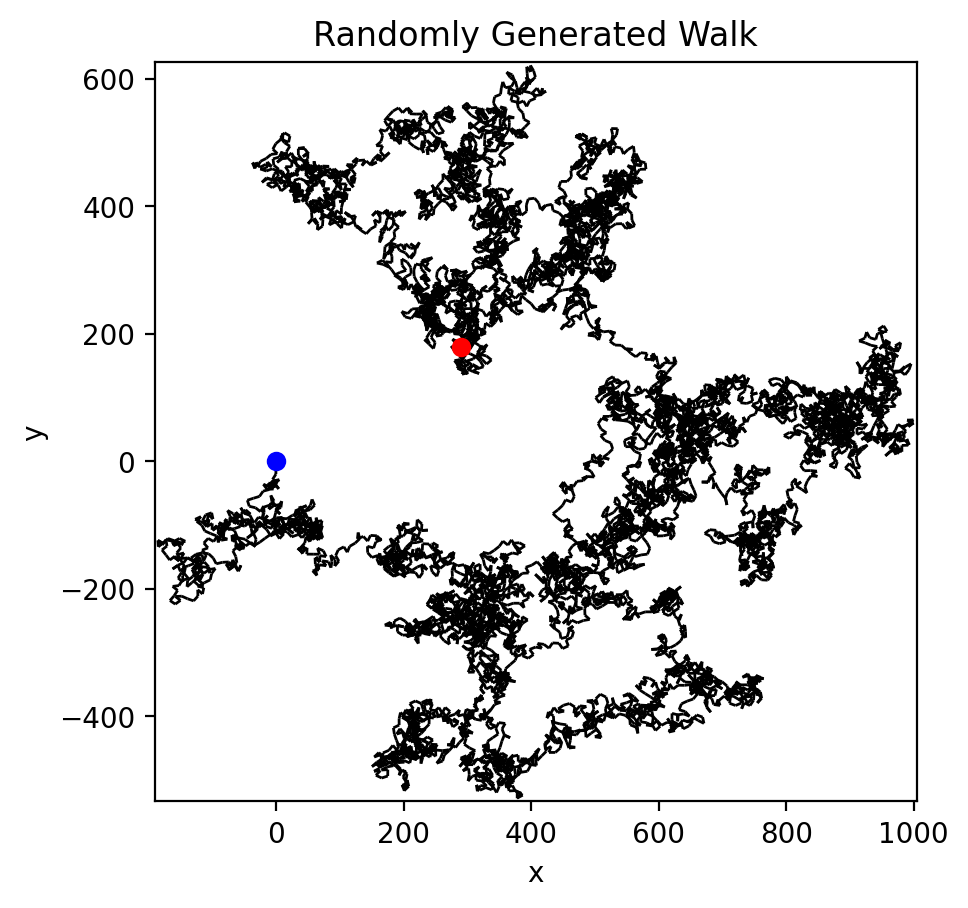

In [45]:
path = randomWalkGenerator(length)
lines, colors = lineGenerator(path, length)
plot_path(path, lines, colors)

## Execute - plot average distance squared against number of steps

In [ ]:
start, end = 20, 1000
length_step_size = 20
plot_r_sqr_against_n(start, end, length_step_size, iterations=250)